In [1]:
import io
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, interpolate
from sklearn import metrics
from scifit import solvers

https://stackoverflow.com/questions/79715602/when-using-scipy-optimize-curve-fit-what-is-the-optimal-formulation-of-the-funct

In [2]:
data = pd.read_csv(io.StringIO("""x,y
410.0,73.06578085929756
25.0,205.29417389522575
72.0,110.48653325137172
51.0,168.52111516008628
15.0,119.75684720989004
72.0,164.46280991735537
73.0,145.53126751391522
36.0,161.41429319490925
40.0,219.91735537190084
190.0,89.18717804003897
21.0,203.3350571291969
47.0,170.12964176670877
21.0,197.1020714822368
18.0,96.43526170798899
53.0,117.55060034305319
50.0,189.89358650365415
43.0,179.03132807995385
863.0,69.63888057656149
71.0,131.42730764753813
40.0,205.2892561983471
65.0,131.3857292219426
401.0,133.81511047189076
50.0,115.65603442387814
58.0,151.99074870050802
50.0,165.8640803223824
21.0,210.87942861045792
236.0,124.21734182739671
53.0,180.11451429366744
12.0,320.77043917765184
36.0,244.3526170798898
25.0,202.41568198893515
21.0,184.03895128162597
29.0,165.64724945771087
25.0,218.1818181818182
72.0,161.8457300275482
130.0,107.38232466256511
84.0,177.52397865095088
38.0,57.524112172378224
50.0,168.132777815723
25.0,202.41568198893515
21.0,244.3978260657449
48.0,168.3167133392528
200.0,122.8403797554812
37.0,167.84185838731295
83.0,173.75445583988846
13.0,315.835929660122
11.0,314.47181327653976
32.0,203.68741889215215
200.0,123.96694214876034
39.0,110.59353869271226
39.0,190.81504521023686
40.0,235.53719008264466
37.0,181.71111484409758
25.0,215.55576804863057
40.0,235.53719008264466"""))

In [3]:
x, y = data.values.T

In [4]:
def model(x, a, b, c):
    return a + b * np.power(x, c)

In [5]:
popt1, pcov1 = optimize.curve_fit(model, x, y, maxfev=5000)
popt1, pcov1

(array([ 3.41534090e+05, -3.41197803e+05,  1.24065941e-04]),
 array([[ 1.74216071e+17, -1.74216049e+17, -6.32913165e+07],
        [-1.74216049e+17,  1.74216027e+17,  6.32913085e+07],
        [-6.32913165e+07,  6.32913085e+07,  2.29932336e-02]]))

In [6]:
yhat1 = model(x, *popt1)

In [7]:
r21 = metrics.r2_score(y, yhat1)
r21

0.43762613423356367

In [8]:
mse1 = metrics.mean_squared_error(y, yhat1)
mse1

1810.4340941731368

In [9]:
popt2, pcov2 = optimize.curve_fit(model, x, y, p0=[1, 1, -1])
popt2, pcov2

/tmp/ipykernel_8399/560780274.py:2: RuntimeWarning: overflow encountered in power
  return a + b * np.power(x, c)
/tmp/ipykernel_8399/560780274.py:2: RuntimeWarning: overflow encountered in multiply
  return a + b * np.power(x, c)


(array([ 7.71246775e+01,  7.48393030e+02, -5.59069711e-01]),
 array([[ 1.85496697e+03,  1.39667392e+04, -1.07159347e+01],
        [ 1.39667392e+04,  1.57727056e+05, -1.01260107e+02],
        [-1.07159347e+01, -1.01260107e+02,  7.02313675e-02]]))

In [10]:
yhat2 = model(x, *popt2)

In [11]:
r22 = metrics.r2_score(y, yhat2)
r22

0.47861759640853596

In [12]:
mse2 = metrics.mean_squared_error(y, yhat2)
mse2

1678.4714529319097

In [13]:
popt3, pcov3 = optimize.curve_fit(model, x, y, bounds=[(0, 0, -10), (1e3, 1e4, 0)])
popt3, pcov3

(array([ 7.71366691e+01,  7.48506385e+02, -5.59148317e-01]),
 array([[ 1.85332690e+03,  1.39685427e+04, -1.07117327e+01],
        [ 1.39685427e+04,  1.57907758e+05, -1.01328166e+02],
        [-1.07117327e+01, -1.01328166e+02,  7.02424633e-02]]))

In [14]:
yhat3 = model(x, *popt3)

In [15]:
r23 = metrics.r2_score(y, yhat3)
r23

0.47861759629841993

In [16]:
mse3 = metrics.mean_squared_error(y, yhat3)
mse3

1678.4714532864032

In [17]:
def callback(intermediate_result: optimize.OptimizeResult):
    print(intermediate_result.x)

In [18]:
def loss_factory(x, y):
    def wrapped(parameters):
        return metrics.mean_squared_error(y, model(x, *parameters))
    return wrapped

In [19]:
loss = loss_factory(x, y)

In [20]:
sol4 = optimize.minimize(loss, x0=[1e5, -1e5, 0])
sol4

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 1810.5828469935145
        x: [ 1.002e+05 -9.983e+04  4.233e-04]
      nit: 5
      jac: [-1.373e-04  5.280e-03 -7.163e+01]
 hess_inv: [[ 3.090e+00  2.138e+00  1.279e-05]
            [ 2.138e+00  3.186e+00  1.304e-05]
            [ 1.279e-05  1.304e-05  6.637e-11]]
     nfev: 232
     njev: 55

In [21]:
sol5 = optimize.minimize(loss, x0=[1, 1, 1])
sol5

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 1678.4714526948019
        x: [ 7.713e+01  7.484e+02 -5.591e-01]
      nit: 61
      jac: [-5.341e-04 -1.221e-04 -1.978e-01]
 hess_inv: [[ 1.994e-04 -2.974e-04 -3.619e-06]
            [-2.974e-04  4.955e-04  5.900e-06]
            [-3.619e-06  5.900e-06  1.014e-05]]
     nfev: 320
     njev: 80

In [22]:
def residuals_factory(x, y):
    def wrapped(parameters):
        return y - model(x, *parameters)
    return wrapped

In [23]:
residuals = residuals_factory(x, y)

In [24]:
optimize.least_squares(residuals, x0=[1, 1, 1])

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-2.996e+01  4.408e+00 ...  1.467e+01  6.325e+01]
           x: [ 7.712e+01  7.484e+02 -5.591e-01]
        cost: 46157.96496987098
         jac: [[-1.000e+00 -3.462e-02 -1.559e+02]
               [-1.000e+00 -1.654e-01 -3.984e+02]
               ...
               [-1.000e+00 -1.654e-01 -3.984e+02]
               [-1.000e+00 -1.272e-01 -3.511e+02]]
        grad: [-2.747e-05 -9.891e-06  9.193e-01]
  optimality: 0.9193335257696162
 active_mask: [ 0.000e+00  0.000e+00  0.000e+00]
        nfev: 25
        njev: 23

In [25]:
sol6 = optimize.least_squares(residuals, x0=[1, 1, 1], method="lm", max_nfev=5000)

In [26]:
xlin = np.linspace(x.min(), x.max(), 200)

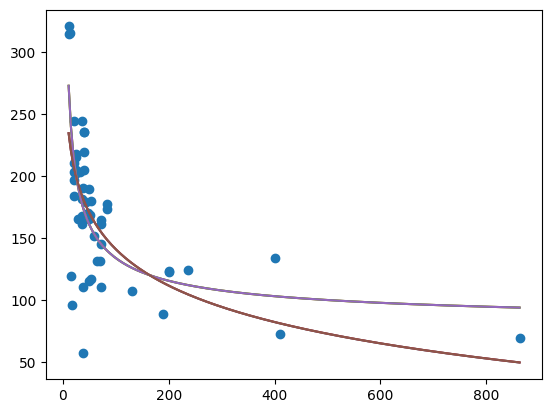

In [27]:
fig, axe = plt.subplots()
axe.scatter(x, y)
axe.plot(xlin, model(xlin, *popt1))
axe.plot(xlin, model(xlin, *popt2))
axe.plot(xlin, model(xlin, *popt3))
axe.plot(xlin, model(xlin, *sol4.x))
axe.plot(xlin, model(xlin, *sol5.x))
axe.plot(xlin, model(xlin, *sol6.x))

In [28]:
def vectorized_loss_factory(x, y):
    @np.vectorize
    def wrapped(a, b, c):
        return metrics.mean_squared_error(y, model(x, a, b, c))
    return wrapped

In [29]:
vloss = vectorized_loss_factory(x, y)

In [165]:
n = 200
b0lin = np.linspace(0, 375000, n)
b1lin = np.linspace(-375000, 25000, n)
b2lin = np.linspace(-1, 1, n)

In [166]:
B0, B1 = np.meshgrid(b0lin, b1lin)
B01 = np.array([B0.ravel(), B1.ravel()]).T

In [167]:
B = np.array([
    [0, 0, 0],
    [1, 1, 1],
    popt1,
    popt2,
])

In [168]:
interpolator01 = interpolate.RBFInterpolator(B[:,[0,1]], B[:,2], smoothing=0.0, epsilon=1., kernel="gaussian")

In [169]:
B201 = interpolator01(B01).reshape(B0.shape)

In [170]:
L01 = vloss(B0, B1, B201)

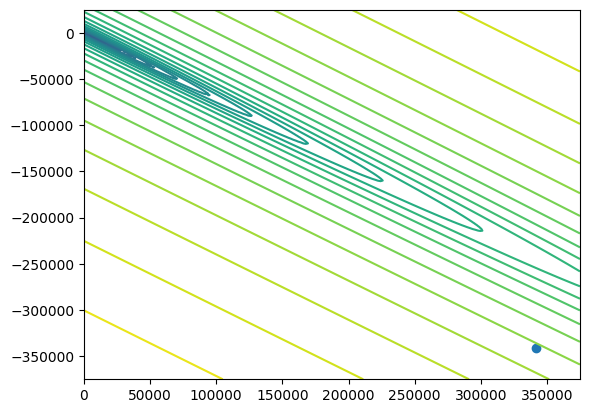

In [171]:
fig, axe = plt.subplots()
axe.contour(B0, B1, np.log10(L01), levels=30)
axe.scatter(*B[:,[0,1]].T)

In [172]:
B0, B2 = np.meshgrid(b0lin, b2lin)
B02 = np.array([B0.ravel(), B2.ravel()]).T

In [173]:
interpolator02 = interpolate.RBFInterpolator(B[:,[0,2]], B[:,1], smoothing=0.0, epsilon=1., kernel="gaussian")

In [174]:
B202 = interpolator01(B02).reshape(B0.shape)

In [175]:
L02 = vloss(B0, B1, B202)

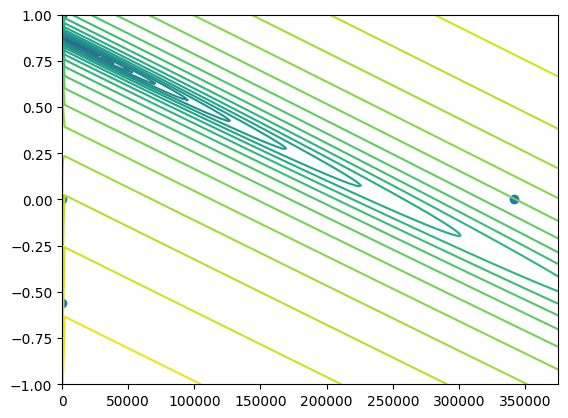

In [176]:
fig, axe = plt.subplots()
axe.contour(B0, B2, np.log10(L02), levels=30)
axe.scatter(*B[:,[0,2]].T)

In [36]:
popt1

array([ 3.41534090e+05, -3.41197803e+05,  1.24065941e-04])

In [37]:
popt2

array([ 7.71246775e+01,  7.48393030e+02, -5.59069711e-01])

In [38]:
class Solver(solvers.FitSolver1D):
    @staticmethod
    def model(x, a, b, c):
        return model(x[:,0], a, b, c)

In [39]:
solver1 = Solver()
sol7 = solver1.fit(x.reshape(-1, 1), y, p0=popt1)

In [40]:
solver2 = Solver()
sol8 = solver2.fit(x.reshape(-1, 1), y, p0=[1, 1, -1])

/tmp/ipykernel_8399/560780274.py:2: RuntimeWarning: overflow encountered in power
  return a + b * np.power(x, c)
/tmp/ipykernel_8399/560780274.py:2: RuntimeWarning: overflow encountered in multiply
  return a + b * np.power(x, c)


In [41]:
domains = pd.DataFrame({
    "min": np.minimum(sol7["parameters"], sol8["parameters"]) * 1.1 - 0.2,
    "max": np.maximum(sol7["parameters"], sol8["parameters"]) * 1.1 + 0.5,
}).T
domains = pd.DataFrame({
    "min": [0, -375000, -1],
    "max": [375000, 25000, 1]
}).T
domains

,0,1,2
min,0,-375000,-1
max,375000,25000,1


In [42]:
sol8["parameters"][[0, 1]]

array([ 77.12467749, 748.39303043])

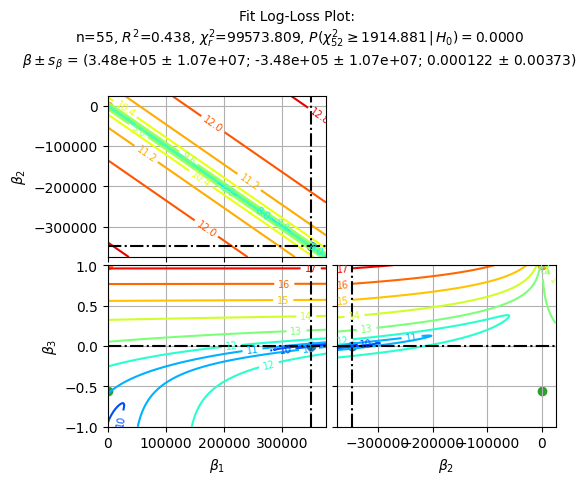

In [43]:
axes = solver1.plot_loss(
    log_loss=True,
    domains=domains,
    resolution=200,
    levels=10,
)
for i in range(2):
    for j in range(i + 1):
        axes[i][j].scatter(1, 1)
        #axes[i][j].scatter(*sol8["parameters"][[j, i]])
axes[1][1].scatter(*sol8["parameters"][[1, 2]])
axes[1][0].scatter(*sol8["parameters"][[0, 2]])

array([[<Axes: ylabel='$\\beta_{2}$'>, <Axes: >],
       [<Axes: xlabel='$\\beta_{1}$', ylabel='$\\beta_{3}$'>,
        <Axes: xlabel='$\\beta_{2}$'>]], dtype=object)

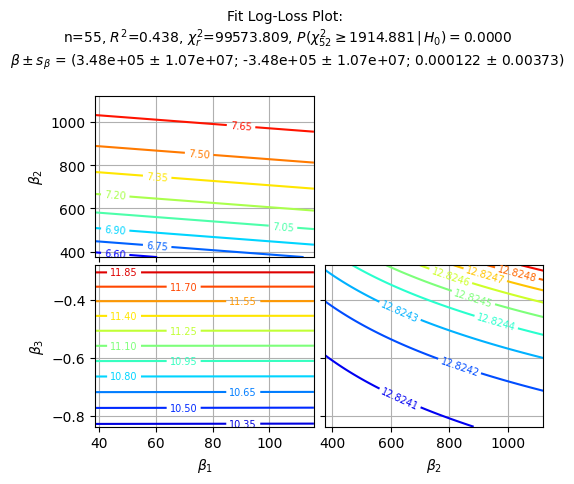

In [44]:
solver1.plot_loss(log_loss=True, domains=solver2.parameter_domains())

array([[<Axes: ylabel='$\\beta_{2}$'>, <Axes: >],
       [<Axes: xlabel='$\\beta_{1}$', ylabel='$\\beta_{3}$'>,
        <Axes: xlabel='$\\beta_{2}$'>]], dtype=object)

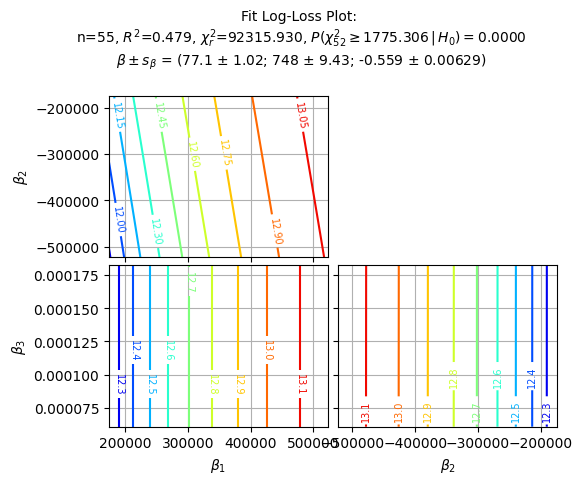

In [45]:
solver2.plot_loss(log_loss=True, domains=solver1.parameter_domains())

In [46]:
levels = [4.5, 5, 5.5, 6, 7, 10, 11, 12]

array([[<Axes: ylabel='$\\beta_{2}$'>, <Axes: >],
       [<Axes: xlabel='$\\beta_{1}$', ylabel='$\\beta_{3}$'>,
        <Axes: xlabel='$\\beta_{2}$'>]], dtype=object)

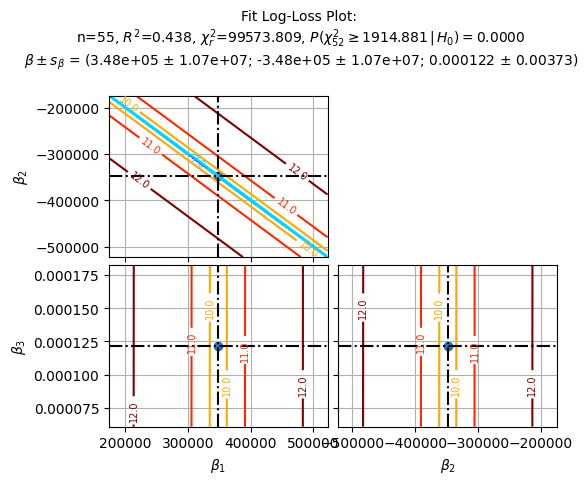

In [47]:
solver1.plot_loss(log_loss=True, levels=levels)

array([[<Axes: ylabel='$\\beta_{2}$'>, <Axes: >],
       [<Axes: xlabel='$\\beta_{1}$', ylabel='$\\beta_{3}$'>,
        <Axes: xlabel='$\\beta_{2}$'>]], dtype=object)

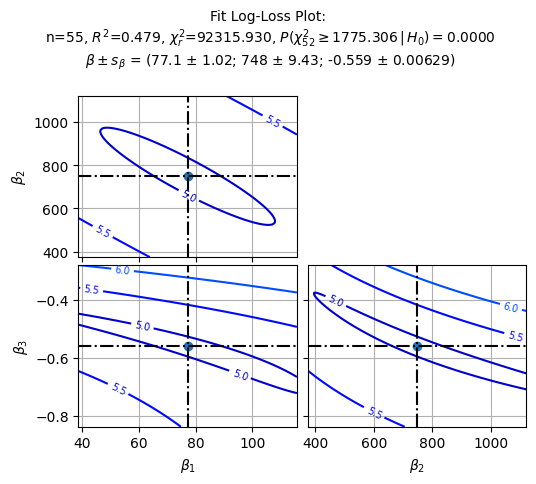

In [48]:
solver2.plot_loss(log_loss=True, levels=levels)